In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('student_mental_health_burnout_1M.csv')
df.head()


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10692 non-null  int64  
 1   gender                10692 non-null  object 
 2   academic_year         10692 non-null  int64  
 3   study_hours_per_day   10692 non-null  float64
 4   exam_pressure         10691 non-null  float64
 5   academic_performance  10691 non-null  float64
 6   stress_level          10691 non-null  float64
 7   anxiety_score         10691 non-null  float64
 8   depression_score      10691 non-null  float64
 9   sleep_hours           10691 non-null  float64
 10  physical_activity     10691 non-null  float64
 11  social_support        10691 non-null  float64
 12  screen_time           10691 non-null  float64
 13  internet_usage        10691 non-null  float64
 14  financial_stress      10691 non-null  float64
 15  family_expectation 

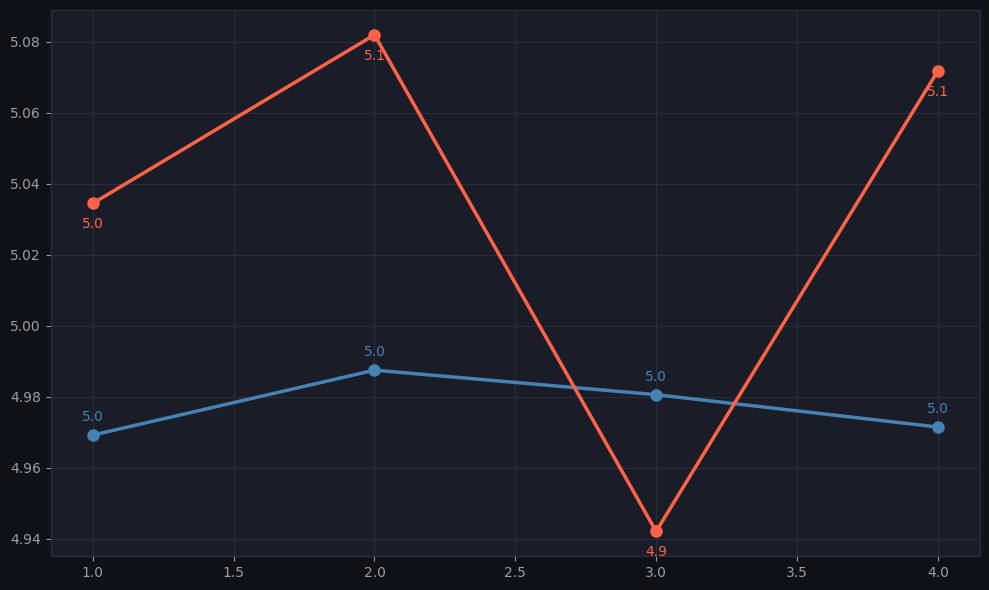

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Group by academic_year and gender, then compute mean
grouped = df.groupby(['academic_year', 'gender'])['study_hours_per_day'].mean().unstack()

plt.figure(figsize=(10, 6))

plt.plot(grouped.index, grouped['Male'], marker='o', label='Male',
         color='steelblue', linewidth=2.5, markersize=8)
plt.plot(grouped.index, grouped['Female'], marker='o', label='Female',
         color='tomato', linewidth=2.5, markersize=8)

# Annotate each point with its value
for year in grouped.index:
    plt.annotate(f"{grouped['Male'][year]:.1f}",
                 xy=(year, grouped['Male'][year]),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', color='steelblue', fontsize=10)
    plt.annotate(f"{grouped['Female'][year]:.1f}",
                 xy=(year, grouped['Female'][year]),
                 xytext=(0, -18), textcoords='offset points',
                 ha='center', color='tomato', fontsize=10)
plt.tight_layout()
plt.show()



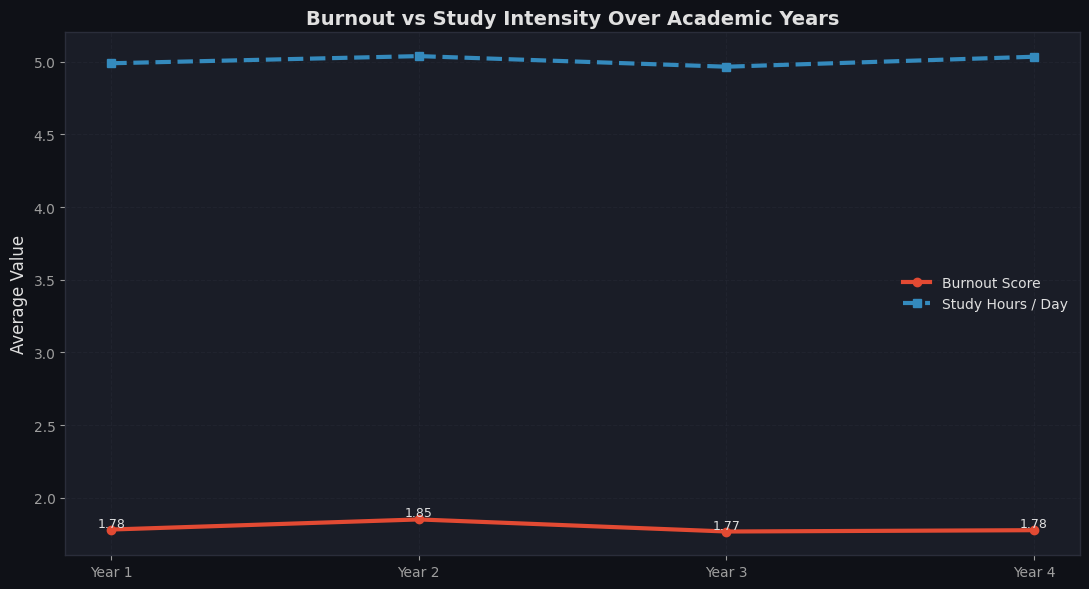

In [36]:
import matplotlib.pyplot as plt

years = sorted(df['academic_year'].unique())
year_labels = [f'Year {y}' for y in years]

g = df.groupby('academic_year')

burnout = g['burnout_score'].mean().values
study = g['study_hours_per_day'].mean().values

plt.figure(figsize=(11,6))

plt.plot(year_labels, burnout, marker='o', linewidth=3, label='Burnout Score')
plt.plot(year_labels, study, marker='s', linewidth=3, linestyle='--',
         label='Study Hours / Day')

for i in range(len(year_labels)):
    plt.text(year_labels[i], burnout[i], f'{burnout[i]:.2f}',
             ha='center', va='bottom', fontsize=9)

plt.title('Burnout vs Study Intensity Over Academic Years',
          fontsize=14, weight='bold')
plt.ylabel('Average Value')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

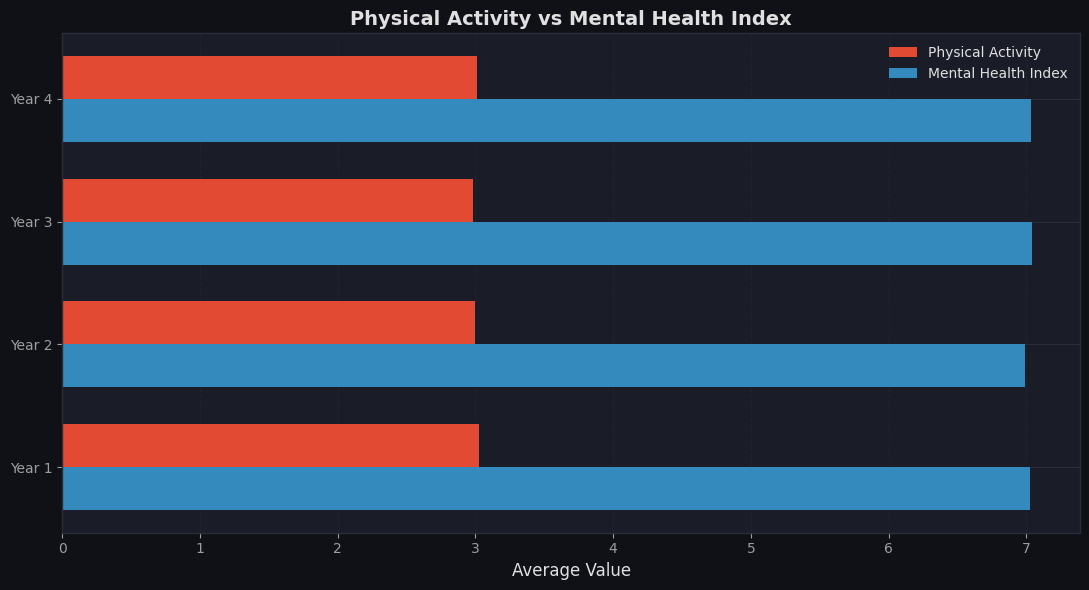

In [38]:
import matplotlib.pyplot as plt
import numpy as np

years = sorted(df['academic_year'].unique())
year_labels = [f'Year {y}' for y in years]
x = np.arange(len(years))
h = 0.35

g = df.groupby('academic_year')

activity = g['physical_activity'].mean().values
mental = g['mental_health_index'].mean().values

plt.figure(figsize=(11,6))

plt.barh(x + h/2, activity, h, label='Physical Activity')
plt.barh(x - h/2, mental, h, label='Mental Health Index')

plt.yticks(x, year_labels)
plt.xlabel('Average Value')
plt.title('Physical Activity vs Mental Health Index',
          fontsize=14, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

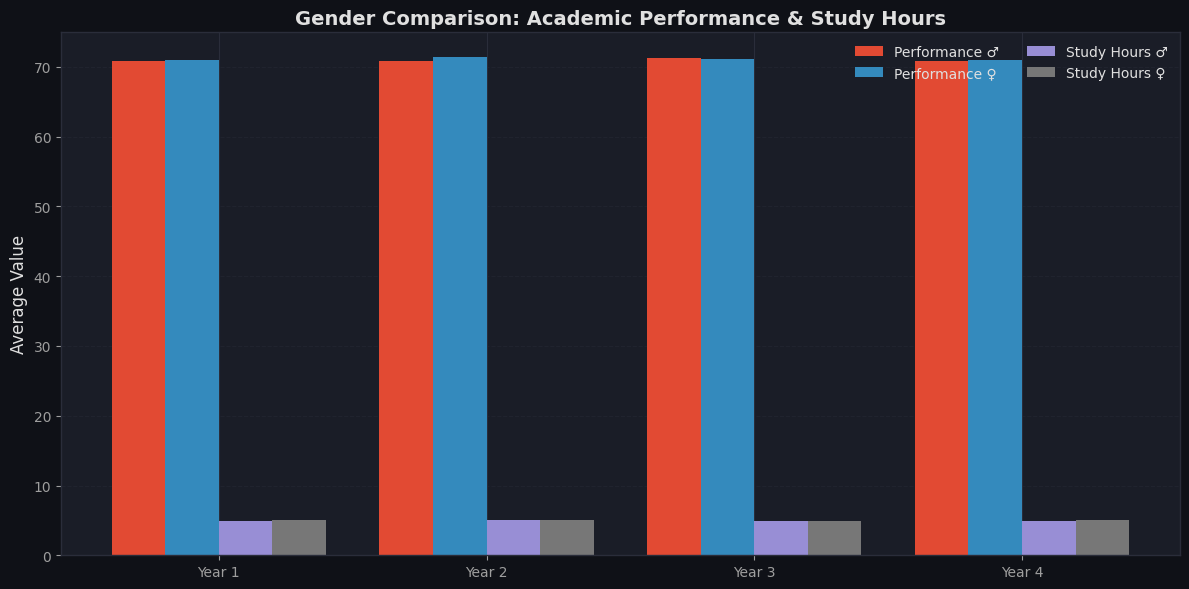

In [40]:
import matplotlib.pyplot as plt
import numpy as np

years = sorted(df['academic_year'].unique())
year_labels = [f'Year {y}' for y in years]
x = np.arange(len(years))
w = 0.2

gm = df[df['gender'] == 'Male'].groupby('academic_year')
gf = df[df['gender'] == 'Female'].groupby('academic_year')

pm = gm['academic_performance'].mean().values
pf = gf['academic_performance'].mean().values
sm = gm['study_hours_per_day'].mean().values
sf = gf['study_hours_per_day'].mean().values

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*w, pm, w, label='Performance ♂')
plt.bar(x - 0.5*w, pf, w, label='Performance ♀')
plt.bar(x + 0.5*w, sm, w, label='Study Hours ♂')
plt.bar(x + 1.5*w, sf, w, label='Study Hours ♀')

plt.xticks(x, year_labels)
plt.ylabel('Average Value')
plt.title('Gender Comparison: Academic Performance & Study Hours',
          fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

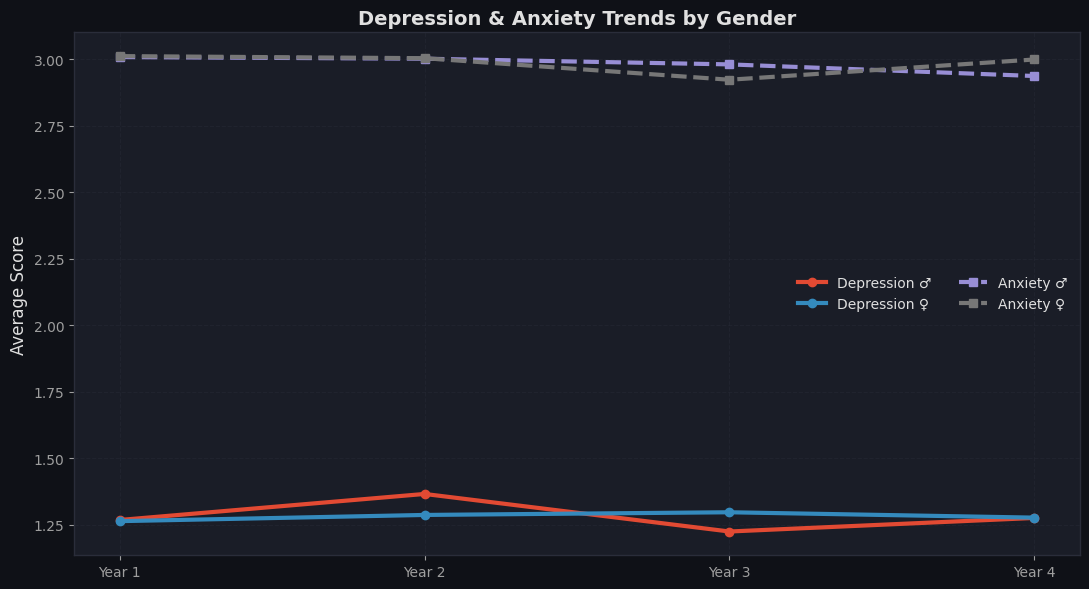

In [41]:
import matplotlib.pyplot as plt

years = sorted(df['academic_year'].unique())
year_labels = [f'Year {y}' for y in years]

gm = df[df['gender'] == 'Male'].groupby('academic_year')
gf = df[df['gender'] == 'Female'].groupby('academic_year')

dm = gm['depression_score'].mean().values
df_ = gf['depression_score'].mean().values
am = gm['anxiety_score'].mean().values
af = gf['anxiety_score'].mean().values

plt.figure(figsize=(11,6))

plt.plot(year_labels, dm, marker='o', linewidth=3,
         label='Depression ♂')
plt.plot(year_labels, df_, marker='o', linewidth=3,
         label='Depression ♀')

plt.plot(year_labels, am, marker='s', linestyle='--', linewidth=3,
         label='Anxiety ♂')
plt.plot(year_labels, af, marker='s', linestyle='--', linewidth=3,
         label='Anxiety ♀')

plt.title('Depression & Anxiety Trends by Gender',
          fontsize=14, weight='bold')
plt.ylabel('Average Score')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()


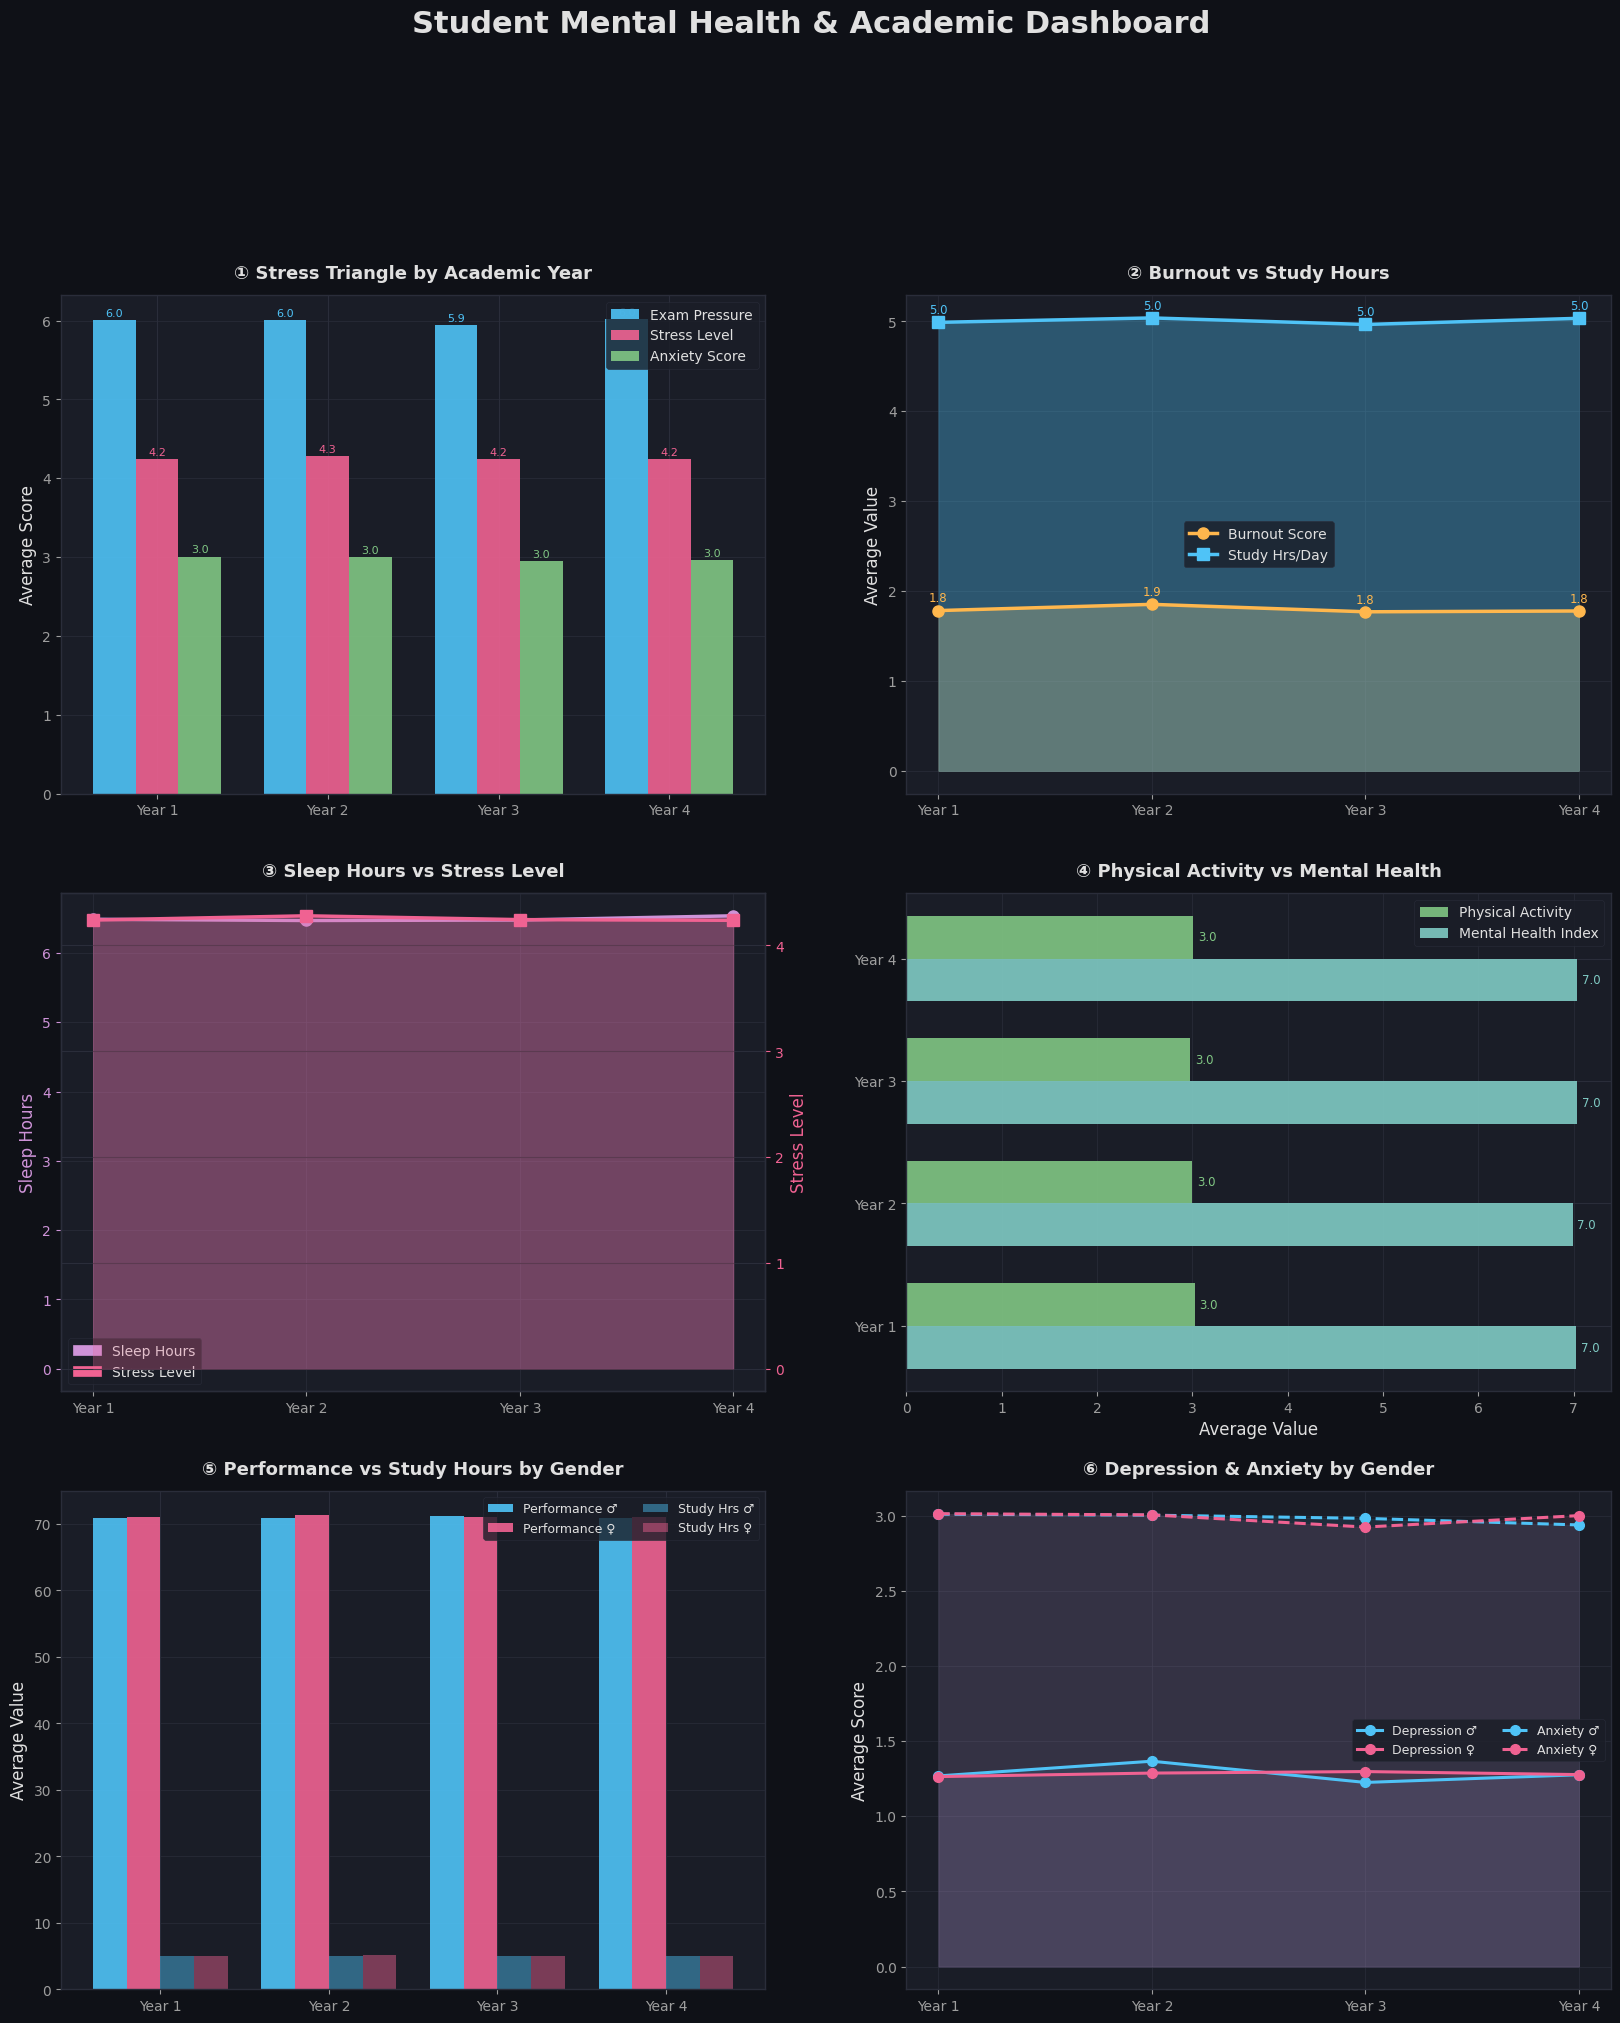

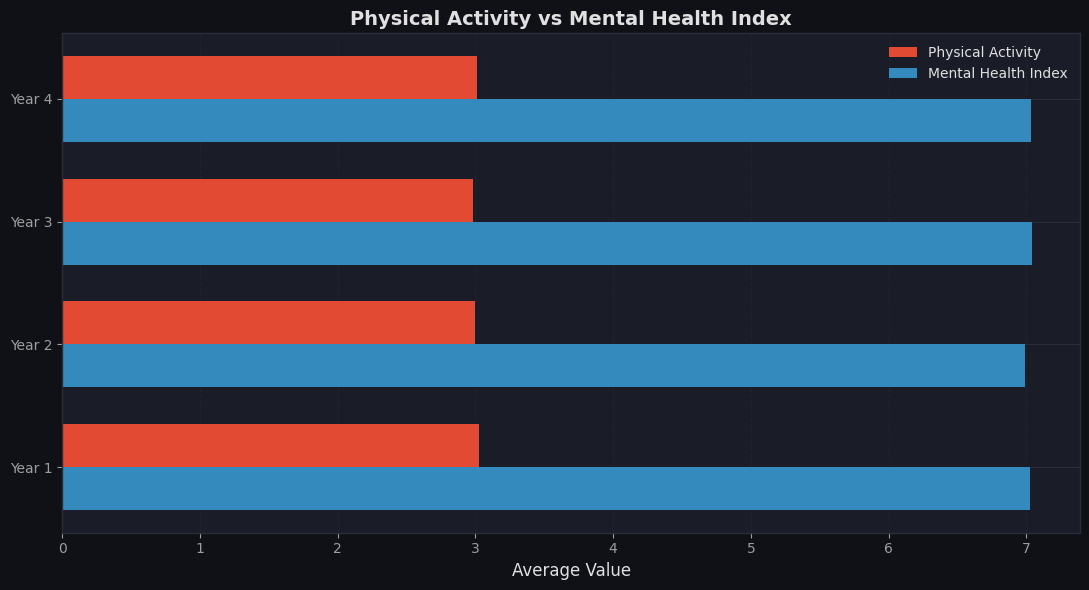

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Palette & Style ──────────────────────────────────────────────────────────
BG        = '#0f1117'
PANEL     = '#1a1d27'
GRID      = '#2a2d3a'
COLORS    = ['#4fc3f7', '#f06292', '#81c784', '#ffb74d', '#ce93d8', '#80cbc4']
TEXT      = '#e0e0e0'
SUBTEXT   = '#9e9e9e'

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : PANEL,
    'axes.edgecolor'    : GRID,
    'axes.labelcolor'   : TEXT,
    'axes.titlecolor'   : TEXT,
    'xtick.color'       : SUBTEXT,
    'ytick.color'       : SUBTEXT,
    'grid.color'        : GRID,
    'legend.facecolor'  : PANEL,
    'legend.edgecolor'  : GRID,
    'legend.labelcolor' : TEXT,
    'text.color'        : TEXT,
    'font.family'       : 'DejaVu Sans',
})

fig, axes = plt.subplots(3, 2, figsize=(20, 22))
fig.suptitle('Student Mental Health & Academic Dashboard',
             fontsize=22, fontweight='bold', color=TEXT, y=1.01)
fig.patch.set_facecolor(BG)

years      = sorted(df['academic_year'].unique())
year_labels = [f'Year {y}' for y in years]
x          = np.arange(len(years))
g          = df.groupby('academic_year')
gm         = df[df['gender'] == 'Male'].groupby('academic_year')
gf         = df[df['gender'] == 'Female'].groupby('academic_year')

# ── 1. Stress Triangle — Grouped Bar ────────────────────────────────────────
ax = axes[0, 0]
w  = 0.25
ep = g['exam_pressure'].mean().values
sl = g['stress_level'].mean().values
ax_= g['anxiety_score'].mean().values

ax.bar(x - w, ep, w, label='Exam Pressure', color=COLORS[0], alpha=0.9)
ax.bar(x,     sl, w, label='Stress Level',  color=COLORS[1], alpha=0.9)
ax.bar(x + w, ax_, w, label='Anxiety Score', color=COLORS[2], alpha=0.9)

for xi, (a, b, c) in enumerate(zip(ep, sl, ax_)):
    ax.text(xi - w, a + 0.05, f'{a:.1f}', ha='center', fontsize=8, color=COLORS[0])
    ax.text(xi,     b + 0.05, f'{b:.1f}', ha='center', fontsize=8, color=COLORS[1])
    ax.text(xi + w, c + 0.05, f'{c:.1f}', ha='center', fontsize=8, color=COLORS[2])

ax.set_title('① Stress Triangle by Academic Year', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x); ax.set_xticklabels(year_labels)
ax.set_ylabel('Average Score'); ax.legend(); ax.grid(axis='y', linewidth=0.5)
ax.set_axisbelow(True)

# ── 2. Burnout vs Study Hours — Area Chart ───────────────────────────────────
ax  = axes[0, 1]
bu  = g['burnout_score'].mean().values
sh  = g['study_hours_per_day'].mean().values

ax.fill_between(year_labels, bu, alpha=0.35, color=COLORS[3])
ax.fill_between(year_labels, sh, alpha=0.35, color=COLORS[0])
ax.plot(year_labels, bu, marker='o', color=COLORS[3], linewidth=2.5, markersize=8, label='Burnout Score')
ax.plot(year_labels, sh, marker='s', color=COLORS[0], linewidth=2.5, markersize=8, label='Study Hrs/Day')

for i, (a, b) in enumerate(zip(bu, sh)):
    ax.text(i, a + 0.1, f'{a:.1f}', ha='center', fontsize=8.5, color=COLORS[3])
    ax.text(i, b + 0.1, f'{b:.1f}', ha='center', fontsize=8.5, color=COLORS[0])

ax.set_title('② Burnout vs Study Hours', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Average Value'); ax.legend(); ax.grid(linewidth=0.5)
ax.set_axisbelow(True)

# ── 3. Sleep vs Stress — Dual-Axis Area ──────────────────────────────────────
ax   = axes[1, 0]
ax2  = ax.twinx()
slp  = g['sleep_hours'].mean().values
str_ = g['stress_level'].mean().values

ax.fill_between(year_labels, slp, alpha=0.25, color=COLORS[4])
ax.plot(year_labels, slp, marker='o', color=COLORS[4], linewidth=2.5, markersize=8, label='Sleep Hours')
ax2.fill_between(year_labels, str_, alpha=0.25, color=COLORS[1])
ax2.plot(year_labels, str_, marker='s', color=COLORS[1], linewidth=2.5, markersize=8, label='Stress Level')

ax.set_ylabel('Sleep Hours', color=COLORS[4]); ax.tick_params(axis='y', colors=COLORS[4])
ax2.set_ylabel('Stress Level', color=COLORS[1]); ax2.tick_params(axis='y', colors=COLORS[1])
ax2.spines['right'].set_color(GRID)

handles = [mpatches.Patch(color=COLORS[4], label='Sleep Hours'),
           mpatches.Patch(color=COLORS[1], label='Stress Level')]
ax.set_title('③ Sleep Hours vs Stress Level', fontsize=13, fontweight='bold', pad=12)
ax.legend(handles=handles, loc='lower left'); ax.grid(linewidth=0.5); ax.set_axisbelow(True)

# ── 4. Physical Activity vs Mental Health — Horizontal Bar ───────────────────
ax  = axes[1, 1]
pa  = g['physical_activity'].mean().values
mh  = g['mental_health_index'].mean().values
h   = 0.35

ax.barh(x + h/2, pa, h, label='Physical Activity', color=COLORS[2], alpha=0.9)
ax.barh(x - h/2, mh, h, label='Mental Health Index', color=COLORS[5], alpha=0.9)

for xi, (a, b) in enumerate(zip(pa, mh)):
    ax.text(a + 0.05, xi + h/2, f'{a:.1f}', va='center', fontsize=8.5, color=COLORS[2])
    ax.text(b + 0.05, xi - h/2, f'{b:.1f}', va='center', fontsize=8.5, color=COLORS[5])

ax.set_yticks(x); ax.set_yticklabels(year_labels)
ax.set_title('④ Physical Activity vs Mental Health', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Average Value'); ax.legend(); ax.grid(axis='x', linewidth=0.5)
ax.set_axisbelow(True)

# ── 5. Academic Performance vs Study Hours by Gender — Grouped Bar ───────────
ax = axes[2, 0]
w  = 0.2
pm = gm['academic_performance'].mean().values
pf = gf['academic_performance'].mean().values
sm = gm['study_hours_per_day'].mean().values
sf = gf['study_hours_per_day'].mean().values

ax.bar(x - 1.5*w, pm, w, label='Performance ♂', color=COLORS[0], alpha=0.9)
ax.bar(x - 0.5*w, pf, w, label='Performance ♀', color=COLORS[1], alpha=0.9)
ax.bar(x + 0.5*w, sm, w, label='Study Hrs ♂',   color=COLORS[0], alpha=0.45)
ax.bar(x + 1.5*w, sf, w, label='Study Hrs ♀',   color=COLORS[1], alpha=0.45)

ax.set_title('⑤ Performance vs Study Hours by Gender', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x); ax.set_xticklabels(year_labels)
ax.set_ylabel('Average Value'); ax.legend(ncol=2, fontsize=9)
ax.grid(axis='y', linewidth=0.5); ax.set_axisbelow(True)

# ── 6. Depression & Anxiety by Gender — Area Chart ───────────────────────────
ax = axes[2, 1]
dm = gm['depression_score'].mean().values
df_= gf['depression_score'].mean().values
am = gm['anxiety_score'].mean().values
af = gf['anxiety_score'].mean().values

for vals, color, label, ls in [
    (dm, COLORS[0], 'Depression ♂', '-'),
    (df_, COLORS[1], 'Depression ♀', '-'),
    (am, COLORS[0], 'Anxiety ♂',    '--'),
    (af, COLORS[1], 'Anxiety ♀',    '--'),
]:
    ax.fill_between(year_labels, vals, alpha=0.1, color=color)
    ax.plot(year_labels, vals, marker='o', color=color, linewidth=2.2,
            markersize=7, linestyle=ls, label=label)

ax.set_title('⑥ Depression & Anxiety by Gender', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Average Score'); ax.legend(ncol=2, fontsize=9)
ax.grid(linewidth=0.5); ax.set_axisbelow(True)

import matplotlib.pyplot as plt
import numpy as np

years = sorted(df['academic_year'].unique())
year_labels = [f'Year {y}' for y in years]
x = np.arange(len(years))
h = 0.35

g = df.groupby('academic_year')

activity = g['physical_activity'].mean().values
mental = g['mental_health_index'].mean().values

plt.figure(figsize=(11,6))

plt.barh(x + h/2, activity, h, label='Physical Activity')
plt.barh(x - h/2, mental, h, label='Mental Health Index')

plt.yticks(x, year_labels)
plt.xlabel('Average Value')
plt.title('Physical Activity vs Mental Health Index',
          fontsize=14, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.legend(frameon=False)


plt.tight_layout(h_pad=3.5, w_pad=2.5)
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 4. Dashboard Trends and Insights

The dashboard, visualized in cell `9cca2a7e`, presents a multi-faceted view of student mental health and academic factors across different academic years and genders. Here's a summary of the observed trends:

*   **① Stress Triangle by Academic Year**: Exam pressure, stress levels, and anxiety scores remain relatively consistent across all academic years, hovering around an average score of 6 for exam pressure and 3 for stress and anxiety. There isn't a dramatic increase or decrease in these metrics as students progress through their academic journey, suggesting these are constant challenges.

*   **② Burnout vs Study Hours**: Both burnout scores and study hours per day show a steady pattern across academic years. Study hours are consistently around 5 hours per day, while burnout scores are around 1.8. There's a slight fluctuation, but no pronounced trend indicating a significant change in either metric over the years.

*   **③ Sleep Hours vs Stress Level**: Sleep hours average around 6.5 hours, while stress levels are around 4.2. These metrics also exhibit a stable trend across academic years. The dual-axis chart highlights their relationship, showing that as stress levels slightly fluctuate, sleep hours tend to follow a similar pattern, suggesting a potential inverse correlation or influence.

*   **④ Physical Activity vs Mental Health**: Physical activity and mental health index remain relatively stable across academic years, averaging around 3 for physical activity and 7 for mental health index. This plot suggests a consistent level of physical activity and overall mental well-being throughout the academic journey, with no significant decline or improvement.

*   **⑤ Performance vs Study Hours by Gender**: Academic performance for both males and females is consistently high, averaging around 71, with minimal variation across academic years. Similarly, study hours per day are stable for both genders, averaging around 5 hours. There's little difference in academic performance or study hours between male and female students, indicating similar academic habits and outcomes.

*   **⑥ Depression & Anxiety by Gender**: Depression and anxiety scores for both male and female students are consistently around 1.3 for depression and 3 for anxiety. The scores are stable across academic years and show very little difference between genders, suggesting that these mental health challenges affect both equally and consistently throughout their academic career.

### 5. Correlation Analysis

To understand the relationships between different numerical variables, let's compute and visualize the correlation matrix.

In [22]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
print('Correlation Matrix for Numerical Columns:')
display(correlation_matrix.style.background_gradient(cmap='coolwarm', axis=None).set_properties(**{'font-size': '8pt'}))

Correlation Matrix for Numerical Columns:


,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
age,1.000000,-0.007715,0.006751,-0.001295,0.011681,-0.000223,0.004344,0.010859,-0.010782,0.000175,0.002873,-0.005393,-0.004335,-0.003666,0.001839,0.011839,-0.004457,0.016199
academic_year,-0.007715,1.000000,0.003326,-0.000952,0.002299,-0.002855,-0.013849,-0.000748,0.011844,-0.004749,0.003997,0.007212,0.008271,0.012987,-0.006170,-0.006504,0.006440,0.000003
study_hours_per_day,0.006751,0.003326,1.000000,0.771123,0.396808,0.357206,0.274182,0.233490,-0.008957,-0.001917,-0.014228,0.005570,0.007130,-0.011635,0.001644,0.348204,-0.342767,0.189929
exam_pressure,-0.001295,-0.000952,0.771123,1.000000,0.139918,0.464123,0.355656,0.303148,0.000633,0.000618,-0.008282,-0.001781,-0.003314,-0.002678,0.001460,0.440799,-0.445093,0.245733
academic_performance,0.011681,0.002299,0.396808,0.139918,1.000000,0.064603,0.048714,0.048324,0.006611,0.005980,-0.015811,-0.007145,-0.008030,-0.010605,0.004507,0.070247,-0.063416,0.033536
stress_level,-0.000223,-0.002855,0.357206,0.464123,0.064603,1.000000,0.761820,0.626190,-0.267672,-0.168662,-0.007224,0.001635,-0.006167,0.465050,0.333527,0.754093,-0.949820,0.560878
anxiety_score,0.004344,-0.013849,0.274182,0.355656,0.048714,0.761820,1.000000,0.473547,-0.205329,-0.125452,-0.005019,-0.004207,-0.009260,0.358405,0.257798,0.666985,-0.867172,0.468847
depression_score,0.010859,-0.000748,0.233490,0.303148,0.048324,0.626190,0.473547,1.000000,-0.165686,-0.102379,-0.371069,0.015873,0.013818,0.295231,0.205488,0.652457,-0.765652,0.653718
sleep_hours,-0.010782,0.011844,-0.008957,0.000633,0.006611,-0.267672,-0.205329,-0.165686,1.000000,0.003143,-0.007029,-0.005924,0.000828,-0.005922,-0.000232,-0.372484,0.254181,-0.180613
physical_activity,0.000175,-0.004749,-0.001917,0.000618,0.005980,-0.168662,-0.125452,-0.102379,0.003143,1.000000,0.008361,-0.001749,0.009992,0.004732,0.014033,-0.105645,0.158236,-0.070787


#### Interpretation of the Correlation Matrix:

*   **Positive Correlation (closer to 1)**: Indicates that as one variable increases, the other tends to increase as well. For example, 'exam_pressure' and 'stress_level' might show a strong positive correlation.
*   **Negative Correlation (closer to -1)**: Indicates that as one variable increases, the other tends to decrease. For example, 'sleep_hours' and 'stress_level' might have a negative correlation.
*   **No Correlation (closer to 0)**: Suggests little to no linear relationship between the variables.

This matrix can help identify key drivers of mental health issues or academic performance, such as strong correlations between 'burnout_score' and 'stress_level', or 'academic_performance' and 'study_hours_per_day'.